In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
(ds_train, ds_test), ds_info = tfds.load(
    "stanford_dogs",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

NUM_CLASSES = ds_info.features["label"].num_classes
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stanford_dogs/incomplete.4S462D_0.2.0/stanford_dogs-train.tfrecord*...:   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stanford_dogs/incomplete.4S462D_0.2.0/stanford_dogs-test.tfrecord*...:   0…

Dataset stanford_dogs downloaded and prepared to /root/tensorflow_datasets/stanford_dogs/0.2.0. Subsequent calls will reuse this data.


In [4]:
def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

In [5]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [6]:
train_size = int(0.9 * ds_info.splits["train"].num_examples)

ds_train = ds_train.map(preprocess)
ds_test = ds_test.map(preprocess)

ds_val = ds_train.skip(train_size)
ds_train = ds_train.take(train_size)

ds_train = ds_train.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_val = ds_val.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_test = ds_test.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [7]:
def build_model(use_augmentation=False):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False  # freeze

    inputs = tf.keras.Input(shape=(224, 224, 3))

    x = inputs

    if use_augmentation:
        x = data_augmentation(x)

    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [9]:
model_no_aug = build_model(use_augmentation=False)

history_no_aug = model_no_aug.fit(
    ds_train,
    validation_data=ds_val,
    epochs=10
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 526s 2s/step - accuracy: 0.4258 - loss: 2.3243 - val_accuracy: 0.7150 - val_loss: 1.0053
Epoch 2/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 516s 2s/step - accuracy: 0.6775 - loss: 1.0700 - val_accuracy: 0.7417 - val_loss: 0.8267
Epoch 3/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 531s 1s/step - accuracy: 0.7421 - loss: 0.8354 - val_accuracy: 0.7608 - val_loss: 0.8089
Epoch 4/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 482s 1s/step - accuracy: 0.7808 - loss: 0.7028 - val_accuracy: 0.7500 - val_loss: 0.7874
Epoch 5/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 486s 1s/step - accuracy: 0.8095 - loss: 0.5936 - val_accuracy: 0.7600 - val_loss: 0.7611
Epoch 6/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 498s 1s/step - accuracy: 0.8304 - loss: 0.5278 - val_accuracy: 0.7600 - val_loss: 0.7899
Epoch 7/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 493s 1s/step - accuracy: 0.8556 - loss: 0.4532 - val_accuracy: 0.7650 - val_loss: 0.8043
Epoch 8/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 496s 1s/

In [10]:
model_aug = build_model(use_augmentation=True)

history_aug = model_aug.fit(
    ds_train,
    validation_data=ds_val,
    epochs=10
)

Epoch 1/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 604s 2s/step - accuracy: 0.2975 - loss: 2.9415 - val_accuracy: 0.6608 - val_loss: 1.1855
Epoch 2/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 570s 2s/step - accuracy: 0.5214 - loss: 1.6973 - val_accuracy: 0.7183 - val_loss: 0.9329
Epoch 3/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 564s 2s/step - accuracy: 0.5724 - loss: 1.4982 - val_accuracy: 0.7192 - val_loss: 0.8893
Epoch 4/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 633s 2s/step - accuracy: 0.6052 - loss: 1.3514 - val_accuracy: 0.7300 - val_loss: 0.8704
Epoch 5/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 609s 2s/step - accuracy: 0.6231 - loss: 1.2933 - val_accuracy: 0.7383 - val_loss: 0.8389
Epoch 6/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 582s 2s/step - accuracy: 0.6415 - loss: 1.2205 - val_accuracy: 0.7425 - val_loss: 0.8294
Epoch 7/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 561s 2s/step - accuracy: 0.6532 - loss: 1.1704 - val_accuracy: 0.7467 - val_loss: 0.8223
Epoch 8/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 560s 2s/step - accuracy: 0.6647 - loss: 1.1192 - val_accu

In [11]:
test_loss_no_aug, test_acc_no_aug = model_no_aug.evaluate(ds_test)
test_loss_aug, test_acc_aug = model_aug.evaluate(ds_test)

269/269 ━━━━━━━━━━━━━━━━━━━━ 326s 1s/step - accuracy: 0.7629 - loss: 0.8476
269/269 ━━━━━━━━━━━━━━━━━━━━ 321s 1s/step - accuracy: 0.7439 - loss: 0.8309


In [12]:
results = pd.DataFrame([
    {
        "Model": "Pretrained_no_aug",
        "Train Loss": history_no_aug.history["loss"][-1],
        "Train Accuracy": history_no_aug.history["accuracy"][-1],
        "Validation Loss": history_no_aug.history["val_loss"][-1],
        "Validation Accuracy": history_no_aug.history["val_accuracy"][-1]
    },
    {
        "Model": "Pretrained_aug",
        "Train Loss": history_aug.history["loss"][-1],
        "Train Accuracy": history_aug.history["accuracy"][-1],
        "Validation Loss": history_aug.history["val_loss"][-1],
        "Validation Accuracy": history_aug.history["val_accuracy"][-1]
    }
])

print(results)

               Model  Train Loss  Train Accuracy  Validation Loss  \
0  Pretrained_no_aug    0.313914        0.897037         0.868244   
1     Pretrained_aug    1.058112        0.683889         0.816909   

   Validation Accuracy  
0             0.758333  
1             0.760000  


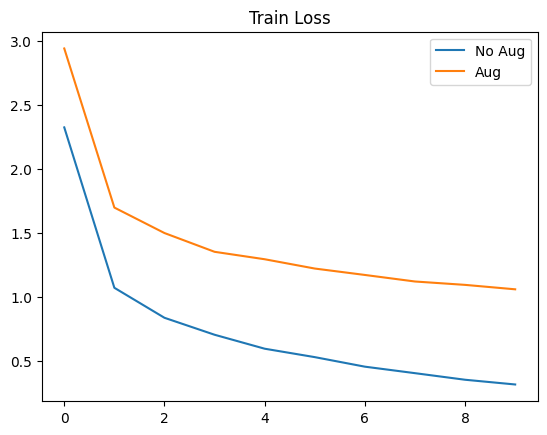

In [13]:
plt.plot(history_no_aug.history["loss"], label="No Aug")
plt.plot(history_aug.history["loss"], label="Aug")
plt.title("Train Loss")
plt.legend()
plt.show()

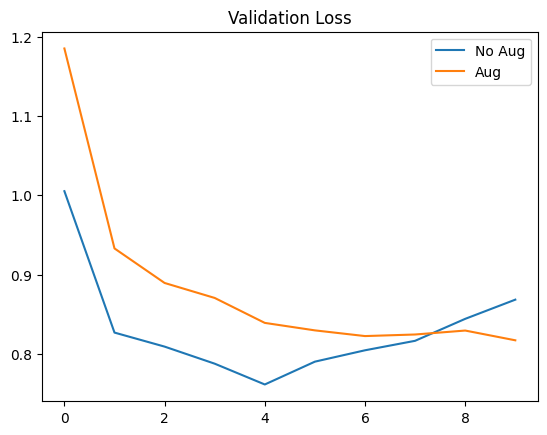

In [14]:
plt.plot(history_no_aug.history["val_loss"], label="No Aug")
plt.plot(history_aug.history["val_loss"], label="Aug")
plt.title("Validation Loss")
plt.legend()
plt.show()

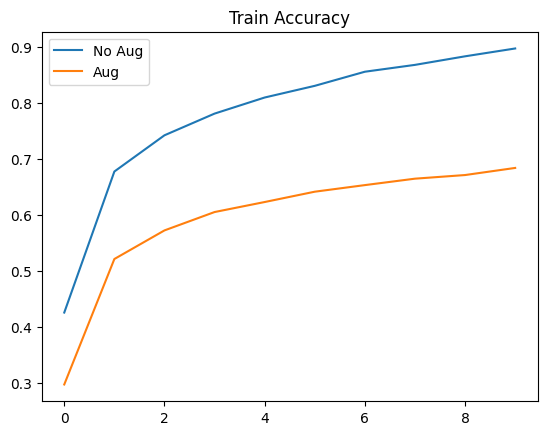

In [15]:
plt.plot(history_no_aug.history["accuracy"], label="No Aug")
plt.plot(history_aug.history["accuracy"], label="Aug")
plt.title("Train Accuracy")
plt.legend()
plt.show()

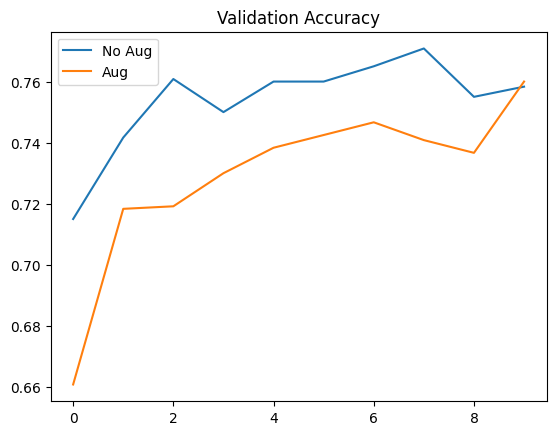

In [16]:
plt.plot(history_no_aug.history["val_accuracy"], label="No Aug")
plt.plot(history_aug.history["val_accuracy"], label="Aug")
plt.title("Validation Accuracy")
plt.legend()
plt.show()